# Sample alignment

This tutorial describes the steps that are taken to set up the beamline and perform sample alignment near the beginning of a beam time. It also allows viewing raw data from scans. For more detailed data reduction and analysis, see other notebooks.


## Imports and other setup

Before using this notebook, ensure that python has been set up correctly (e.g., https://github.com/NSLS-II-SST/rsoxs_workflow/blob/Issue46_PythonSetupExample_Draft/examples/setup_python_miniforge.md)


### Import PyHyperScattering and other libraries as needed


In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import copy
import datetime
import os

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PyHyperScattering as phs
from matplotlib.pyplot import cm

### Load local functions

Below are some functions that can assist data viewing and processing. On the left-hand panel, select the table of contents, right click on the "Load local functions" heading, and click on "Select and Run Cell(s) for this Heading"


#### View and export energy scans


In [3]:
def view_export_energy_scans(
    scan_ids,
    export_scans = False,
    file_path_export = "",
    file_name_export = "",
    signals_to_plot = ["I0", "Photodiode"],
    figure_title = "",
    energies_vline = [],
):
    """
    Load the 1D detector data directly from Tiled and show a basic plot of the raw data and normalized signal.
    In many cases, this code is used to gather several scans across time, which can take a long time to load.
    Thus, the workflow is broken up such that the code below mainly gathers the data and can save into Excel files.
    Then, these Excel files can be loaded to do further processing, which can be more time-efficient than reloading the entire start-to-finish process.

    Args:
        scan_ids: list of int values
            List of scan IDs to process.
        export_scans: bool
            True exports scan data into Excel file.
            Defaults to False to skip export step.
        file_path_export: str
            File path, not including file name, to export data.
            Defaults to empty string corresponding with export_scans = False
        file_name_export: str
            File name of exported data.
            Defaults to empty string corresponding with export_scans = False
        signals_to_plot: list of str values, length 2
            Signals to show in the plots.
            Defaults to I0 and Photodiode signals.  This is useful for open-beam scans which can assess contamination on these detectors or upstream optics, provide a proxy for the beam flux with respect to energy and time, and characterize stability of the normalized signal over time.
            Another option is to use ["I0", "TEY"] for TEY samples, such as HOPG.  This is useful for monitoring shifts in energy calibration or changes to the TEY sample.
        figure_title: str
            Optional title to add to figure
        energies_vlines: list of float values
            Optional list of energies at which vertical lines can be plotted.
            Vertical lines can help mark any features that occur at particular energies.
            Defaults to empty list.

    Returns
    -------
        Optionally explorts scan data into excel file.
        Plots raw and normalized signals.

    Raises
    ------

    Examples
    --------
    """
    ## TODO: use a universal lookup table and function to assign variable names
    ## Use this to include slit currents in the exported data
    ## Plot slit currents by having it as the two signals in the next viewing step.

    offset_timestamp_seconds = 0 ## TODO: revisit if there is a better way to get the correct time.  In Google Colab, sometimes it shifted the timestamp by 4 hours.

    number_rows, number_columns = 1, 3
    fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*5, number_rows*4), edgecolor=(0, 0, 0, 0), linewidth=3) #figsize=(3.25, 3.25) for figure
    fig.suptitle(figure_title, color=(0, 0, 0, 1), fontname="Calibri", size=12)
    ## Ensure axs always stays a 2D array
    if number_rows == 1 and number_columns == 1: axs = np.array([[axs]])
    if number_rows == 1 and number_columns > 1: axs = axs.reshape(1, number_columns)
    if number_rows > 1 and number_columns == 1: axs = axs.reshape(number_rows, 1)
    plot_colors = cm.rainbow(np.linspace(1, 0, len(scan_ids)))

    for index_scan_id, scan_id in enumerate(scan_ids):
        plot_color = plot_colors[index_scan_id]

        ## Load scan
        scan_raw = catalog[int(scan_id)]
        scan_xarray = scan_raw["primary"]["data"].read()
        scan_xarray = scan_xarray.rename_vars({"en_energy": "Energy"})
        scan_xarray = scan_xarray.rename_vars({"RSoXS Au Mesh Current": "I0"})
        scan_xarray = scan_xarray.rename_vars({"DM7 photodiode": "Photodiode"}) #scan_xarray = scan_xarray.rename_vars({"WAXS Beamstop": "Photodiode"})
        scan_xarray = scan_xarray.rename_vars({"RSoXS Sample Current": "TEY"})
        scan = copy.deepcopy(scan_xarray)

        ## Export scan
        if export_scans:
            sheet_name = "ScanID" + str(scan_id)
            scan_dictionary = {
                "Energy": scan["Energy"],
                "I0": scan["I0"],
                "Photodiode": scan["Photodiode"],
                "TEY": scan["TEY"],
                "ScanID": int(scan_id),
                "Timestamp_Seconds": (scan_raw.metadata["start"]["time"] - offset_timestamp_seconds)
            }
            scan_dataframe = pd.DataFrame(scan_dictionary)
            if os.path.exists(os.path.join(file_path_export, file_name_export)):
                with pd.ExcelWriter(os.path.join(file_path_export, file_name_export), mode='a') as writer: ## If the file already exists, it will just add a new sheet, otherwise create a new file.  Or maybe not?  Revisit how this works.
                    scan_dataframe.to_excel(writer, sheet_name=sheet_name, index=True)
            else:
                scan_dataframe.to_excel(os.path.join(file_path_export, file_name_export), sheet_name=sheet_name, index=True)

        ## Gather plot labels and information to print to serve as a progress bar
        polarization = scan_raw["baseline"]["data"]["en_polarization"].read()[0]
        timestamp = str(datetime.datetime.fromtimestamp(int(scan_raw.metadata["start"]["time"] - offset_timestamp_seconds)))
        plot_label = "Scan ID = " + str(scan_id) + ", \nTime = " + str(timestamp)
        print("Scan ID = " + str(scan_id) + ", Time = " + str(timestamp) + ", Polarization = " + str(polarization) + "°")

        ## Plot data
        ax = axs[0, 0]
        ax.plot(scan["Energy"], scan[signals_to_plot[0]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel(str(signals_to_plot[0]), color=(0, 0, 0, 1), size=12)
        ax = axs[0, 1]
        ax.plot(scan["Energy"], scan[signals_to_plot[1]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel((str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)
        ax = axs[0, 2]
        ax.plot(scan["Energy"], scan[signals_to_plot[0]]/scan[signals_to_plot[1]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel((str(signals_to_plot[0]) + " / " + str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)


    ## Mark energies
    for energy_vline in energies_vline:
        for subplot in [0, 1, 2]:
            ax = axs[0, subplot]
            ax.axvline(energy_vline, color=(0, 0, 0, 1), linestyle="dashed")

    ## Plot Formatting
    for index_row in np.arange(0, number_rows, 1):
        for index_column in np.arange(0, number_columns, 1):
            ax = axs[index_row, index_column]
            ## Subplot and axes labels
            ax.set_xlabel("Energy (eV)", color=(0, 0, 0, 1), size=12)
            #ax.set_ylabel("I0", color=(0, 0, 0, 1), size=12)
            ## Axes scaling and ranges
            ax.set_xscale("linear")
            ax.set_yscale("linear")
            #ax.set_xlim([0, 0.08])
            ax.set_ylim(bottom=0, top=None, auto=True)
            ## Border formatting
            for Border in np.array(["top", "bottom", "left", "right"]):
                ax.spines[Border].set_linewidth(2) ## axes/border linewidths
                ax.spines[Border].set_color((0, 0, 0, 1)) ## axes/border colors
            for Axis in np.array(["x", "y"]): ax.tick_params(axis=Axis, colors=(0, 0, 0, 1), width=2)
    axs[0, 2].legend(ncol=1, loc="center left", bbox_to_anchor=(1.05, 0.5), edgecolor=(1, 1, 1, 1))
    plt.tight_layout() ## This ensures that subplots don't overlap

    plt.show()

def view_energy_scans(
    file_path_import,
    file_name_import,
    sheet_names,
    signals_to_plot = ["I0", "Photodiode"],
    darks = [0, 0],
    energy_time_plot = 285,
    figure_title = "",
    energies_vline = [],
):
    """
    This will load energy scan data that has been exported into a spreadsheet.
    The energy scan data is processed further to subtract dark values and to extract the time dependence of signal intensities.

    Args:
        file_path_import: str
            File path to the excel spreadsheet.
        file_name_import: str
            File name of the excel spreadsheet that contains energy scan data.
            The file is organized such that each sheet contains data for a single scan, and the sheet name contains the scan ID.
        sheet_names: list of str values
            A list of the sheet names to process.
            Usually, all sheets in a file are analyzed, but optionally, selected sheet names can be provided.
        signals_to_plot: list of str values, length 2
            Signals to show in the plots.
            Defaults to I0 and Photodiode signals.  This is useful for open-beam scans which can assess contamination on these detectors or upstream optics, provide a proxy for the beam flux with respect to energy and time, and characterize stability of the normalized signal over time.
            Another option is to use ["I0", "TEY"] for TEY samples, such as HOPG.  This is useful for monitoring shifts in energy calibration or changes to the TEY sample.
        darks: list of float values
            A list of dark values for the signals measured.
            Order of dark values is the order of the signals_to_plot list.
            Defaults to 0 dark signal if no dark values are entered.
        energy_time_plot: float
            Energy (eV) at which intensities are extracted to view evolution over time.
        energies_vlines: list of float values
            Optional list of energies at which vertical lines can be plotted.
            Vertical lines can help mark any features that occur at particular energies.
            Defaults to empty list.

    Returns
    -------

    Raises
    ------

    Examples
    --------
    """
    number_rows, number_columns = 2, 3
    fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*5, number_rows*5), edgecolor=(0, 0, 0, 0), linewidth=3) #figsize=(3.25, 3.25) for figure
    ## Ensure axs always stays a 2D array
    if number_rows == 1 and number_columns == 1: axs = np.array([[axs]])
    if number_rows == 1 and number_columns > 1: axs = axs.reshape(1, number_columns)
    if number_rows > 1 and number_columns == 1: axs = axs.reshape(number_rows, 1)
    fig.suptitle((figure_title + "\n Dark_" + str(signals_to_plot[0]) + " = " + str(darks[0]) + ", Dark_" + str(signals_to_plot[1]) + " = " + str(darks[1])), color=(0, 0, 0, 1), size=12)
    plot_colors = cm.rainbow(np.linspace(1, 0, len(sheet_names)))

    ax_y1 = axs[1, 1]
    ax_y2 = ax_y1.twinx()

    for index_sheet_name, sheet_name in enumerate(sheet_names):
        plot_color = plot_colors[index_sheet_name]
        scan = pd.read_excel(os.path.join(file_path_import, file_name_import), sheet_name=sheet_name) ## Opening from excel
        scan_id, timestamp_seconds = int(scan["ScanID"][0]), scan["Timestamp_Seconds"][0]

        timestamp_datetime = datetime.datetime.fromtimestamp(int(timestamp_seconds))

        ## Subtract darks
        for signal_to_plot, dark in zip(signals_to_plot, darks, strict=False):
            scan[signal_to_plot] = scan[signal_to_plot] - dark

        ## Extract signals at selected energy
        signals_single_energy = []
        for signal_to_plot in signals_to_plot:
            scan_sorted_for_interpolation = scan.sort_values(by="Energy").reset_index(drop=True)
            signal_single_energy = np.interp(energy_time_plot,
                                             scan_sorted_for_interpolation["Energy"],
                                             scan_sorted_for_interpolation[signal_to_plot],
                                             left = np.nan, ## Needed to avoid extrapolation for partial datasets that might not contain energy_time_plot within the range of measured energies
                                             right = np.nan,
                                            )
            signals_single_energy.append(signal_single_energy)

        plot_label = " Scan ID = " + str(scan_id)
        print("Scan ID = " + str(scan_id) + ", Time = " + str(timestamp_datetime)) ## Acting as a progress bar

        ax = axs[0, 0]
        ax.plot(scan["Energy"], scan[signals_to_plot[0]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel(str(signals_to_plot[0]), color=(0, 0, 0, 1), size=12)

        ax = axs[0, 1]
        ax.plot(scan["Energy"], scan[signals_to_plot[1]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel((str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)

        ax = axs[0, 2]
        ax.plot(scan["Energy"], scan[signals_to_plot[0]]/scan[signals_to_plot[1]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel((str(signals_to_plot[0]) + " / " + str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)

        datapoint, y_axis_label, y_axis_side, y_axis_offset = signals_single_energy[0], (str(signals_to_plot[0]) + " (filled circles)"), "left", 0
        # Plot data
        ax_y1.plot(timestamp_datetime, datapoint, label="", marker="o", markersize=5, markerfacecolor=plot_color, markeredgecolor=plot_color, linestyle="none")
        ax_y1.set_ylabel(y_axis_label, color=(0, 0, 0, 1), size=12)
        ax_y1.set_ylim(bottom=0, top=None, auto=True)
        ax_y1.yaxis.set_label_position(y_axis_side)
        ax_y1.yaxis.set_ticks_position(y_axis_side)
        datapoint, y_axis_label, y_axis_side, y_axis_offset = signals_single_energy[1], (str(signals_to_plot[1]) + " signal (hollow squares)"), "right", 0
        # Plot data
        ax_y2.plot(timestamp_datetime, datapoint, label="", marker="s", markersize=5, markerfacecolor="none", markeredgecolor=plot_color, linestyle="none")
        if index_sheet_name != (len(sheet_names) - 1): ax_y2.set_ylabel(y_axis_label, color=(0, 0, 0, 0), size=12)
        else: ax_y2.set_ylabel(y_axis_label, color=(0, 0, 0, 1), size=12)
        ax_y2.set_ylim(bottom=0, top=None, auto=True)
        ax_y2.yaxis.set_label_position(y_axis_side)
        ax_y2.yaxis.set_ticks_position(y_axis_side)

        ax = axs[1, 2]
        ax.plot(timestamp_datetime, (signals_single_energy[0]/signals_single_energy[1]), label="", marker="o", markersize=5, markerfacecolor=plot_color, markeredgecolor=plot_color, linestyle="none")
        ax.set_ylabel((str(signals_to_plot[0]) + " / " + str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)


    ## Mark energies
    for energy_vline in energies_vline:
        for subplot in [0, 1, 2]:
            ax = axs[0, subplot]
            ax.axvline(energy_vline, color=(0, 0, 0, 1), linestyle="dashed")

    ## Plot Formatting
    for index_row in np.arange(0, number_rows, 1):
        for index_column in np.arange(0, number_columns, 1):
            ax = axs[index_row, index_column]
            ## Subplot and axes labels
            if index_row == 1 and index_column > 0: ax.set_title((f"Energy = {energy_time_plot} eV"), color=(0, 0, 0, 1), size=12)
            if index_row == 0: ax.set_xlabel("Energy (eV)", color=(0, 0, 0, 1), size=12)
            #ax.set_ylabel("I0", color=(0, 0, 0, 1), size=12)
            ## Axes scaling and ranges
            ax.set_xscale("linear")
            ax.set_yscale("linear")
            #ax.set_xlim([0, 0.08])
            ax.set_ylim(bottom=0, top=None, auto=True)
            ## Border formatting
            for Border in np.array(["top", "bottom", "left", "right"]):
                ax.spines[Border].set_linewidth(2) ## axes/border linewidths
                ax.spines[Border].set_color((0, 0, 0, 1)) ## axes/border colors
            for Axis in np.array(["x", "y"]): ax.tick_params(axis=Axis, colors=(0, 0, 0, 1), width=2)
            if index_row == 1:
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
                for label in ax.get_xticklabels():
                    label.set_rotation(45)
                    label.set_horizontalalignment('right')
    axs[1, 0].axis('off') ## To remove plot and axes and have a blank spot
    plt.tight_layout() ## This ensures that subplots don't overlap

    plt.show()


Python tip: learn more about a function using ? or ?? after the function name. A single ? will show the docstring. A double ?? will show the full source code. See examples below.


## Access beamline data

Enter BNL credentials and 2-factor authentication when prompted. The catalog will include a list of scan IDs to which you have access.

If accessing data from locally saved files, skip this step.


In [4]:
loader = phs.load.SST1RSoXSDB(corr_mode="none")

catalog = loader.c
catalog

could not directly connect to Tiled using a system profile.
  Making network connection.
  Enter your BNL credentials now or pass an api key like catalog_kwargs={"api_key":"..."}.
NOTICE TO USERS

This is a Federal computer system (and/or it is directly connected to a BNL local network system) and is the property of the United States Government. It is for authorized use only. Users (authorized or unauthorized) have no explicit or implicit expectation of privacy.

Any or all uses of this system and all files on this system may be intercepted, monitored, recorded, copied, audited, inspected, and disclosed to authorized site, Department of Energy, and law enforcement personnel, as well as authorized officials of other agencies, both domestic and foreign. By using this system, the user consents to such interception, monitoring, recording, copying, auditing, inspection, and disclosure at the discretion of authorized site or Department of Energy personnel.

Unauthorized or improper use of th

<Catalog {91703, 91704, 91705, 91706, 91707, 91708, 91709, ...} ~1777 entries>

If accessing data on a shared/public computer, it can be good to check that you are logged in as yourself so that you can access scans that belong to you. Run the code below without modifying anything.


In [5]:
## Run without modifying anything
username_logged_in = catalog.context.whoami()['identities'][0]['id']
print("Logged into Tiled as: " + username_logged_in)

Logged into Tiled as: hheilman


If the above username is not yours, log out using the code below, and then log back in using the first block of code at the top of this section.


In [ ]:
catalog.logout()

## (Optional) Search for scans

Narrow down search parameters as needed to find the desired scan from the NSLS II SST1 RSoXS station. Various examples are shown in the comments.

If the desired scans are not found in this summary, check that you are listed as an experimenter in the beam time proposal (https://pass.bnl.gov/).

If accessing data from locally saved files, skip this step.


In [12]:
loader.browseCatalog()

Retrieving results:   0%|          | 0/1777 [00:00<?, ?it/s]

/Users/hduva/projects/pyref/.venv/lib/python3.13/site-packages/PyHyperScattering/SST1RSoXSDB.py:190: UserWarning: One or more missing field(s) during this load were replaced with "N/A".  Re-run with debugWarnings=True to see details.
  self.catalog_df = self.searchCatalog(**kwargs)


Grid(columns_fit='size_to_fit', compress_data=True, export_mode='disabled', height='350px', menu={'buttons': […

In [23]:
filtered_scan_list = loader.searchCatalog(
    cycle="2026-1",
    institution="WSU",
    sample_id="HOPG"
)
filtered_scan_list

Retrieving results:   0%|          | 0/35 [00:00<?, ?it/s]

/var/folders/r8/f7plnn3j0pl84gbjlks1md7h0000gn/T/ipykernel_25122/2745645119.py:1: UserWarning: One or more missing field(s) during this load were replaced with "N/A".  Re-run with debugWarnings=True to see details.
  filtered_scan_list = loader.searchCatalog(


,scan_id,start_time,cycle,institution,project,sample_name,sample_id,plan,detector,exit_status,num_Images,uid,sample_id
0,106719,2026-02-19 08:13:16.150294,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,00b958d4-36ea-4d2b-b7da-255bd2bb3ded,HOPG_NIST
1,106720,2026-02-19 08:25:20.451096,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,a413f8b2-d2e8-4d74-90e7-49db76d654cb,HOPG_NIST
2,106721,2026-02-19 08:38:49.489141,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,ae815641-38a0-483e-8de2-a54c5d19fef9,HOPG_NIST
3,106722,2026-02-19 08:43:51.716952,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,5cfd2257-400a-482d-b6f4-2ded75696979,HOPG_NIST
4,106723,2026-02-19 08:57:03.508352,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,c9924314-aeec-4186-806c-17bac2d6c83b,HOPG_NIST
5,106728,2026-02-19 09:41:00.384624,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,adb7e7e9-1f9f-4637-8080-1f18ebdbd0c9,HOPG_NIST
6,106729,2026-02-19 09:53:09.115550,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,e03abf85-07bb-414b-97c4-bc06941074d8,HOPG_NIST
7,106730,2026-02-19 10:00:05.665111,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,0d04caf7-c2ae-4b7a-b785-6f580fa8fb4f,HOPG_NIST
8,106731,2026-02-19 10:05:41.988324,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,c713d736-696d-42af-a5c1-8b1ac67b0566,HOPG_NIST
9,106732,2026-02-19 10:09:51.389176,2026-1,WSU,Heilman,HOPG_NIST,HOPG_NIST,nbs_list_scan,beamstop_waxs,success,84,747fb8b1-d59a-4b99-b490-1ea3d4923d00,HOPG_NIST


In [39]:
import altair as alt
import panel as pn

pn.extension("tabulator")


def _safe_unique(values):
    return sorted({str(v) for v in values if v is not None and str(v).strip() != ""})


def _as_dataframe(obj):
    if obj is None:
        return pd.DataFrame()
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    if hasattr(obj, "to_pandas"):
        try:
            return obj.to_pandas()
        except Exception:
            pass
    try:
        return pd.DataFrame(obj)
    except Exception:
        return pd.DataFrame()


class RSoXSToyDashboard:
    def __init__(self):
        self.catalog_df = pd.DataFrame()
        self.filtered_df = pd.DataFrame()
        self.scan_cache = {}

        self.cycle = pn.widgets.Select(name="Cycle", options=["Any"], value="Any", width=140)
        self.institution = pn.widgets.Select(name="Institution", options=["Any"], value="Any", width=160)
        self.sample_id = pn.widgets.Select(name="Sample", options=["Any"], value="Any", width=190)
        self.run_type = pn.widgets.Select(name="Run Type", options=["Any"], value="Any", width=200)
        self.query_text = pn.widgets.TextInput(
            name="Extra query",
            placeholder='Optional key="value" pairs, comma separated',
            width=420,
        )
        self.refresh_btn = pn.widgets.Button(name="Refresh catalog", button_type="primary")
        self.apply_btn = pn.widgets.Button(name="Apply filters", button_type="success")

        self.group_by = pn.widgets.Select(
            name="Group by",
            options=["none", "sample_id", "run_type", "sample_id + run_type"],
            value="sample_id + run_type",
            width=220,
        )
        self.visible_columns = pn.widgets.MultiChoice(name="Visible columns", options=[], value=[], width=520)
        self.scan_select = pn.widgets.MultiChoice(name="Scans to plot", options=[], value=[], width=520)

        self.x_var = pn.widgets.Select(name="X", options=[], width=220)
        self.y_var = pn.widgets.Select(name="Y", options=[], width=260)
        self.calc_mode = pn.widgets.Select(
            name="Y transform",
            options=["raw", "nexafs_tey_over_i0", "nexafs_post_edge_norm"],
            value="raw",
            width=220,
        )
        self.post_edge_min = pn.widgets.FloatInput(name="Post-edge min", value=340.0, width=130)
        self.post_edge_max = pn.widgets.FloatInput(name="Post-edge max", value=345.0, width=130)

        self.status = pn.pane.Markdown("", height=35)
        self.group_pane = pn.pane.Markdown("", height=170)
        self.plot_pane = pn.pane.Vega(height=430, sizing_mode="stretch_width")

        self.table = pn.widgets.Tabulator(
            pd.DataFrame(),
            selectable="checkbox",
            pagination="local",
            page_size=12,
            height=320,
            sizing_mode="stretch_width",
        )

        self.refresh_btn.on_click(self.refresh_catalog)
        self.apply_btn.on_click(self.apply_filters)
        self.table.param.watch(self._sync_scans_from_table_selection, "selection")
        self.scan_select.param.watch(self._update_axis_options, "value")

        self.view = pn.Column(
            pn.Row(self.refresh_btn, self.apply_btn, self.status),
            pn.Row(self.cycle, self.institution, self.sample_id, self.run_type),
            self.query_text,
            pn.Row(self.group_by, self.visible_columns),
            self.group_pane,
            self.table,
            pn.Row(self.scan_select),
            pn.Row(self.x_var, self.y_var, self.calc_mode, self.post_edge_min, self.post_edge_max),
            self.plot_pane,
        )

        self.refresh_catalog()

    def _set_status(self, text, error=False):
        self.status.object = f"**Error:** {text}" if error else text

    def _parse_query_text(self):
        kwargs = {}
        txt = (self.query_text.value or "").strip()
        if txt == "":
            return kwargs
        parts = [p.strip() for p in txt.split(",") if p.strip()]
        for p in parts:
            if "=" not in p:
                continue
            k, v = p.split("=", 1)
            kwargs[k.strip()] = v.strip().strip('"').strip("'")
        return kwargs

    def _infer_run_type(self, frame):
        if "plan_name" in frame.columns:
            s = frame["plan_name"].astype(str).str.lower()
            out = np.where(
                s.str.contains("energy|nexafs|xafs", na=False),
                "energy_scan",
                np.where(s.str.contains("angle|th", na=False), "theta_scan", "other"),
            )
            return pd.Series(out, index=frame.index)
        if "scan_type" in frame.columns:
            return frame["scan_type"].astype(str)
        return pd.Series(["unknown"] * len(frame), index=frame.index)

    def _choose_scan_metadata_columns(self, frame):
        preferred = [
            "scan_id",
            "sample_id",
            "run_type",
            "plan_name",
            "cycle",
            "institution",
            "time",
            "uid",
        ]
        cols = [c for c in preferred if c in frame.columns]
        if not cols:
            cols = list(frame.columns)
        return cols[:10]

    def refresh_catalog(self, *_):
        try:
            raw = loader.searchCatalog()
            frame = _as_dataframe(raw)
            if frame.empty:
                self.catalog_df = pd.DataFrame()
                self.filtered_df = pd.DataFrame()
                self.table.value = pd.DataFrame()
                self._set_status("Catalog is empty.", error=True)
                return

            if "scan_id" not in frame.columns:
                frame = frame.reset_index().rename(columns={"index": "scan_id"})

            frame["scan_id"] = frame["scan_id"].astype(str)
            if "sample_id" not in frame.columns:
                frame["sample_id"] = "unknown"
            if "cycle" not in frame.columns:
                frame["cycle"] = "unknown"
            if "institution" not in frame.columns:
                frame["institution"] = "unknown"
            frame["run_type"] = self._infer_run_type(frame)

            self.catalog_df = frame
            self.cycle.options = ["Any"] + _safe_unique(frame["cycle"])
            self.institution.options = ["Any"] + _safe_unique(frame["institution"])
            self.sample_id.options = ["Any"] + _safe_unique(frame["sample_id"])
            self.run_type.options = ["Any"] + _safe_unique(frame["run_type"])
            self.visible_columns.options = self._choose_scan_metadata_columns(frame)
            self.visible_columns.value = list(self.visible_columns.options)
            self.apply_filters()
        except Exception as exc:
            self._set_status(str(exc), error=True)

    def _filtered_catalog(self):
        if self.catalog_df.empty:
            return pd.DataFrame()
        frame = self.catalog_df.copy()
        if self.cycle.value != "Any":
            frame = frame[frame["cycle"].astype(str) == str(self.cycle.value)]
        if self.institution.value != "Any":
            frame = frame[frame["institution"].astype(str) == str(self.institution.value)]
        if self.sample_id.value != "Any":
            frame = frame[frame["sample_id"].astype(str) == str(self.sample_id.value)]
        if self.run_type.value != "Any":
            frame = frame[frame["run_type"].astype(str) == str(self.run_type.value)]

        extra = self._parse_query_text()
        for key, val in extra.items():
            if key in frame.columns:
                frame = frame[frame[key].astype(str) == str(val)]
        return frame

    def _update_group_summary(self):
        if self.filtered_df.empty:
            self.group_pane.object = "No grouped results."
            return
        mode = self.group_by.value
        if mode == "none":
            self.group_pane.object = f"Total scans in view: **{len(self.filtered_df)}**"
            return
        keys = ["sample_id", "run_type"] if mode == "sample_id + run_type" else [mode]
        group = (
            self.filtered_df.groupby(keys, dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )
        self.group_pane.object = group.to_markdown(index=False)

    def apply_filters(self, *_):
        frame = self._filtered_catalog()
        self.filtered_df = frame
        self._update_group_summary()

        if frame.empty:
            self.table.value = pd.DataFrame(columns=self.visible_columns.value)
            self.scan_select.options = []
            self.scan_select.value = []
            self.plot_pane.object = alt.Chart(pd.DataFrame({"x": [], "y": []})).mark_line()
            self._set_status("No scans match your current filter set.", error=True)
            return

        cols = [c for c in self.visible_columns.value if c in frame.columns]
        if not cols:
            cols = self._choose_scan_metadata_columns(frame)
        self.table.value = frame[cols].copy()

        scans = [str(x) for x in frame["scan_id"].tolist()]
        self.scan_select.options = scans
        self.scan_select.value = scans[: min(4, len(scans))]
        self._update_axis_options()
        self._set_status(f"Loaded {len(frame)} scans from catalog view.")

    def _load_scan_data(self, scan_id):
        key = str(scan_id)
        if key in self.scan_cache:
            return self.scan_cache[key]

        run = None
        try:
            run = catalog[key]
        except Exception:
            run = catalog[int(scan_id)]
        ds = run["primary"]["data"].read()
        self.scan_cache[key] = ds
        return ds

    def _sync_scans_from_table_selection(self, *_):
        if self.table.value is None or len(self.table.value) == 0:
            return
        selected_rows = list(self.table.selection or [])
        if not selected_rows:
            return
        table_df = self.table.value
        if "scan_id" not in table_df.columns:
            return
        selected_scan_ids = table_df.iloc[selected_rows]["scan_id"].astype(str).tolist()
        self.scan_select.value = selected_scan_ids[: min(10, len(selected_scan_ids))]
        self._update_axis_options()

    def _candidate_x_vars(self, ds):
        options = []
        variables = set(getattr(ds, "variables", {}).keys())
        for c in ["en_energy", "en_energy_setpoint", "Energy", "time"]:
            if c in variables or c in getattr(ds, "dims", {}):
                options.append(c)
        if not options:
            options.extend(list(getattr(ds, "dims", {}).keys()))
        if not options:
            options.extend(list(getattr(ds, "data_vars", {}).keys()))
        return options

    def _candidate_y_vars(self, ds):
        data_vars = list(getattr(ds, "data_vars", {}).keys())
        preferred = [
            "RSoXS Sample Current",
            "TEY",
            "WAXS Beamstop",
            "DM7 photodiode",
            "Photodiode",
            "RSoXS Au Mesh Current",
            "I0",
        ]
        ordered = [v for v in preferred if v in data_vars]
        for var in data_vars:
            if var not in ordered:
                ordered.append(var)
        return ordered

    def _update_axis_options(self, *_):
        scan_ids = list(self.scan_select.value or [])
        if not scan_ids:
            self.x_var.options = []
            self.y_var.options = []
            self.plot_pane.object = alt.Chart(pd.DataFrame({"x": [], "y": []})).mark_line()
            return
        try:
            ds = self._load_scan_data(scan_ids[0])
            x_opts = self._candidate_x_vars(ds)
            y_opts = self._candidate_y_vars(ds)
            self.x_var.options = x_opts
            self.y_var.options = y_opts
            if x_opts and self.x_var.value not in x_opts:
                self.x_var.value = x_opts[0]
            if y_opts and self.y_var.value not in y_opts:
                self.y_var.value = y_opts[0]
            self._update_plot()
        except Exception as exc:
            self._set_status(str(exc), error=True)

    def _extract_series(self, ds, var_name):
        arr = ds[var_name]
        try:
            values = np.asarray(arr.values).reshape(-1)
        except Exception:
            values = np.asarray(list(arr)).reshape(-1)
        return values

    def _single_scan_frame(self, scan_id, x_name, y_name):
        ds = self._load_scan_data(scan_id)
        x = self._extract_series(ds, x_name)
        y_raw = self._extract_series(ds, y_name)

        n = min(len(x), len(y_raw))
        x = x[:n]
        y_raw = y_raw[:n]

        y_out = y_raw.astype(float)
        if self.calc_mode.value == "nexafs_tey_over_i0":
            i0_name = "I0"
            if i0_name not in getattr(ds, "data_vars", {}):
                if "RSoXS Au Mesh Current" in getattr(ds, "data_vars", {}):
                    i0_name = "RSoXS Au Mesh Current"
                else:
                    return pd.DataFrame({"x": x, "y": np.full_like(x, np.nan, dtype=float), "scan_id": str(scan_id)})
            i0 = self._extract_series(ds, i0_name)[:n].astype(float)
            with np.errstate(divide="ignore", invalid="ignore"):
                y_out = np.where(np.abs(i0) > 0, y_out / i0, np.nan)

        if self.calc_mode.value == "nexafs_post_edge_norm":
            xmin, xmax = float(self.post_edge_min.value), float(self.post_edge_max.value)
            mask = (x >= xmin) & (x <= xmax)
            baseline = np.nanmean(y_out[mask]) if np.any(mask) else np.nan
            if np.isfinite(baseline) and baseline != 0:
                y_out = y_out / baseline
            else:
                y_out = np.full_like(y_out, np.nan, dtype=float)

        frame = pd.DataFrame({"x": x, "y": y_out, "scan_id": str(scan_id)})
        frame = frame.replace([np.inf, -np.inf], np.nan).dropna(subset=["x", "y"])
        return frame

    def _plot_title(self):
        mode_map = {
            "raw": "Raw signal",
            "nexafs_tey_over_i0": "NEXAFS TEY / I0",
            "nexafs_post_edge_norm": "NEXAFS post-edge normalized",
        }
        return mode_map.get(self.calc_mode.value, "Scan plot")

    def _update_plot(self):
        scan_ids = list(self.scan_select.value or [])
        if not scan_ids or not self.x_var.value or not self.y_var.value:
            self.plot_pane.object = alt.Chart(pd.DataFrame({"x": [], "y": []})).mark_line()
            return

        rows = []
        errors = []
        for sid in scan_ids:
            try:
                rows.append(self._single_scan_frame(sid, self.x_var.value, self.y_var.value))
            except Exception as exc:
                errors.append(f"{sid}: {exc}")

        if not rows:
            self.plot_pane.object = alt.Chart(pd.DataFrame({"x": [], "y": []})).mark_line()
            if errors:
                self._set_status("; ".join(errors), error=True)
            return

        plot_df = pd.concat(rows, ignore_index=True)
        chart = (
            alt.Chart(plot_df)
            .mark_line()
            .encode(
                x=alt.X("x:Q", title=self.x_var.value),
                y=alt.Y("y:Q", title=self._plot_title()),
                color=alt.Color("scan_id:N", title="Scan ID"),
                tooltip=["scan_id:N", "x:Q", "y:Q"],
            )
            .properties(title=self._plot_title(), height=400)
            .interactive()
        )
        self.plot_pane.object = chart
        if errors:
            self._set_status("Plotted with some skipped scans: " + "; ".join(errors), error=True)
        else:
            self._set_status(f"Plotted {len(scan_ids)} scan(s).")

    def show(self):
        controls = [
            self.x_var,
            self.y_var,
            self.calc_mode,
            self.post_edge_min,
            self.post_edge_max,
        ]
        for widget in controls:
            widget.param.watch(lambda *_: self._update_plot(), "value")
        return self.view


dash = RSoXSToyDashboard()
dash.show()

Retrieving results:   0%|          | 0/1777 [00:00<?, ?it/s]

/var/folders/r8/f7plnn3j0pl84gbjlks1md7h0000gn/T/ipykernel_25122/976214084.py:146: UserWarning: One or more missing field(s) during this load were replaced with "N/A".  Re-run with debugWarnings=True to see details.
  raw = loader.searchCatalog()


BokehModel(combine_events=True, render_bundle={'docs_json': {'14b826d5-789e-4efb-b691-d844f9de55ae': {'version…

Retrieving results:   0%|          | 0/1777 [00:00<?, ?it/s]

## Characterizing energy resolution


KeyError: 'No match for scan_id=103834'

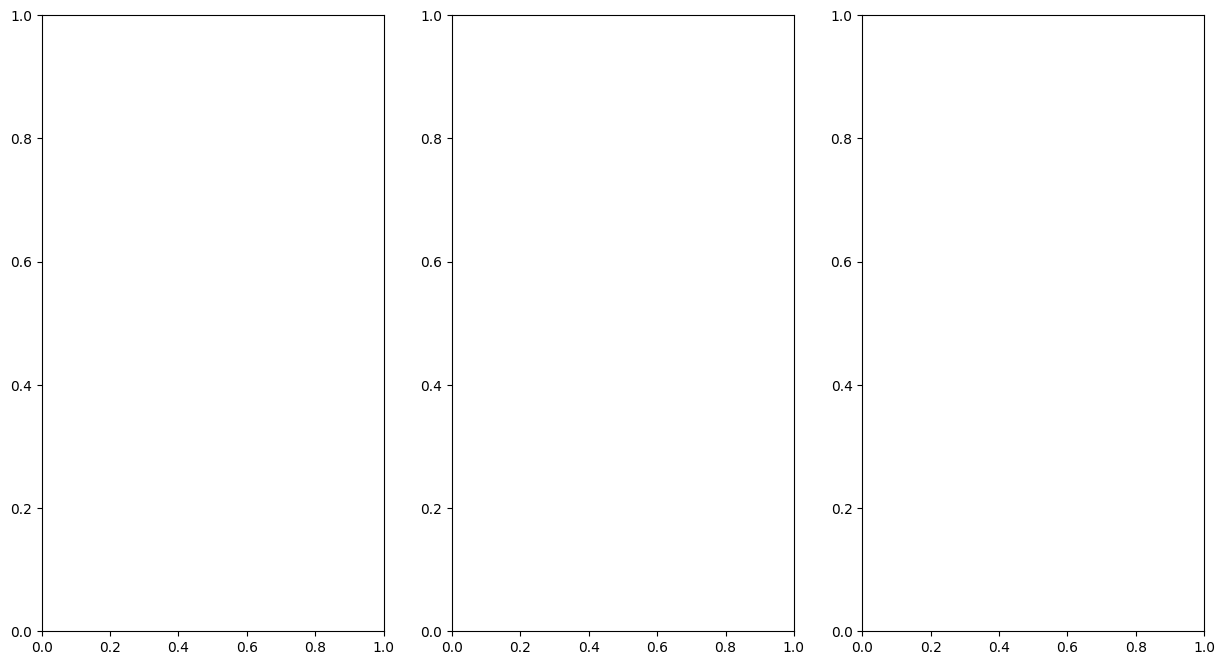

In [36]:
def view_export_HOPG_energy_resolution_scans(
    scan_ids,
    export_scans,
    file_path_export,
    file_name_export,
):

    offset_timestamp_seconds = 0

    number_rows, number_columns = 1, 3
    fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*5, number_rows*8), edgecolor=(0, 0, 0, 0), linewidth=3)#fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*5, number_rows*4), edgecolor=(0, 0, 0, 0), linewidth=3) #figsize=(3.25, 3.25) for figure
    ## Ensure axs always stays a 2D array
    if number_rows == 1 and number_columns == 1: axs = np.array([[axs]])
    if number_rows == 1 and number_columns > 1: axs = axs.reshape(1, number_columns)
    if number_rows > 1 and number_columns == 1: axs = axs.reshape(number_rows, 1)
    plot_colors = cm.rainbow(np.linspace(1, 0, len(scan_ids)))

    for index_scan_id, scan_id in enumerate(scan_ids):
        plot_color = plot_colors[index_scan_id]

        ## Load scan
        scan_raw = catalog[int(scan_id)]
        scan_xarray = scan_raw["primary"]["data"].read()
        scan_xarray = scan_xarray.rename_vars({"en_energy": "Energy"})
        scan_xarray = scan_xarray.rename_vars({"RSoXS Au Mesh Current": "I0"})
        scan_xarray = scan_xarray.rename_vars({"WAXS Beamstop": "Photodiode"})
        scan_xarray = scan_xarray.rename_vars({"RSoXS Sample Current": "TEY"})
        scan_xarray = scan_xarray.swap_dims({"time": "Energy"})
        scan = copy.deepcopy(scan_xarray)

        scan = scan.sortby("Energy")
        slits1_vsize = scan_raw["baseline"]["data"]["Upstream Scatter Slits_vsize_setpoint"].read()[0]

        """
        ## (optional) Sparse out data if needed
        N = scan.dims['Energy']
        indices_to_keep = np.arange(0, N, 3)
        last_index = N - 1
        if last_index not in indices_to_keep:
            # Append the last index to ensure the final energy point is kept
            indices_to_keep = np.append(indices_to_keep, last_index)
        scan = scan.isel(Energy=indices_to_keep)
        """

        ## Export scan
        if export_scans:
            sheet_name = "ScanID" + str(scan_id)
            scan_dictionary = {
                "Energy": scan["Energy"],
                "I0": scan["I0"],
                "TEY": scan["TEY"],
                "Slits1_vsize": slits1_vsize,
                "ScanID": int(scan_id),
                "Timestamp_Seconds": (scan_raw.metadata["start"]["time"] - offset_timestamp_seconds)
            }
            scan_dataframe = pd.DataFrame(scan_dictionary)
            if os.path.exists(os.path.join(file_path_export, file_name_export)):
                with pd.ExcelWriter(os.path.join(file_path_export, file_name_export), mode='a') as writer: ## If the file already exists, it will just add a new sheet, otherwise create a new file.  Or maybe not?  Revisit how this works.
                    scan_dataframe.to_excel(writer, sheet_name=sheet_name, index=True)
            else:
                scan_dataframe.to_excel(os.path.join(file_path_export, file_name_export), sheet_name=sheet_name, index=True)

        ## Gather plot labels and information to print to serve as a progress bar
        polarization = scan_raw["baseline"]["data"]["en_polarization"].read()[0]
        timestamp = str(datetime.datetime.fromtimestamp(int(scan_raw.metadata["start"]["time"] - offset_timestamp_seconds)))
        plot_label = "Scan ID = " + str(scan_id) + ", \nslits1.vsize = " + str(slits1_vsize)
        print("Scan ID = " + str(scan_id) + ", Time = " + str(timestamp) + ", Polarization = " + str(polarization) + "°")

        ## Plot data
        ax = axs[0, 0]
        ax.plot(scan["Energy"], scan["TEY"], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel("Raw sample current", color=(0, 0, 0, 1), size=12)

        start_label = scan["TEY"]["Energy"].sel(Energy=340, method="nearest").item()
        end_label = scan["TEY"]["Energy"].sel(Energy=345, method="nearest").item()
        ax = axs[0, 1]
        ax.plot(scan["Energy"], (scan["TEY"]/scan["TEY"].sel(Energy=slice(start_label, end_label)).mean()), label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel("Raw sample current \n normalized to post-edge", color=(0, 0, 0, 1), size=12)
        ax = axs[0, 2]
        ax.plot(scan["Energy"], (scan["TEY"]/scan["TEY"].sel(Energy=slice(start_label, end_label)).mean()), label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel("Raw sample current \n normalized to post-edge", color=(0, 0, 0, 1), size=12)
        ax.set_xlim([285, 310])

    ## Plot Formatting
    for index_row in np.arange(0, number_rows, 1):
        for index_column in np.arange(0, number_columns, 1):
            ax = axs[index_row, index_column]
            #ax.axvline(291.65, color=(0, 0, 0, 1), linestyle="dashed")
            ## Subplot and axes labels
            ax.set_xlabel("Energy (eV)", color=(0, 0, 0, 1), size=12)
            #ax.set_ylabel("I0", color=(0, 0, 0, 1), size=12)
            ## Axes scaling and ranges
            ax.set_xscale("linear")
            ax.set_yscale("linear")
            #ax.set_xlim([0, 0.08])
            ax.set_ylim(bottom=0, top=None, auto=True)
            ## Border formatting
            for Border in np.array(["top", "bottom", "left", "right"]):
                ax.spines[Border].set_linewidth(2) ## axes/border linewidths
                ax.spines[Border].set_color((0, 0, 0, 1)) ## axes/border colors
            for Axis in np.array(["x", "y"]): ax.tick_params(axis=Axis, colors=(0, 0, 0, 1), width=2)
    axs[0, 2].legend(ncol=1, loc="center left", bbox_to_anchor=(1.05, 0.5), edgecolor=(1, 1, 1, 1))
    plt.tight_layout() ## This ensures that subplots don't overlap

    plt.show()





view_export_HOPG_energy_resolution_scans(
    scan_ids=SCAN_IDS,
    export_scans=EXPORT_SCANS,
    file_path_export=FILE_PATH_EXPORT,
    file_name_export=FILE_NAME_EXPORT,
)

## ---------------------------------------------------------------------------------------------


## ---------------------------------------------------------------------------------------------


## ---------------------------------------------------------------------------------------------


## ---------------------------------------------------------------------------------------------
